In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

import copy

import sys
import pandas.core.indexes
import pickle

import torch.optim as optim
from tqdm.notebook import tqdm

# Фиксируем seed для воспроизводимости результатов диплома
np.random.seed(42)
torch.manual_seed(42)

In [2]:
sys.modules['pandas.indexes'] = pandas.core.indexes

PATH_TO_PKL = 'data/LSWMD.pkl' 

print("Загрузка датасета (это может занять 1-2 минуты)...")
with open(PATH_TO_PKL, 'rb') as f:
    df = pickle.load(f, encoding='latin1')
print(f"Исходный размер датасета: {len(df)} пластин.")

# 1. Фильтруем пустые значения
df = df[df['failureType'].apply(lambda x: len(x) > 0)]

# 2. Переводим метки в строку для удобства фильтрации
df['failureType_str'] = df['failureType'].apply(lambda x: str(x[0][0]).strip())

# 3. Убираем 'Blank', 'none' и пустые строки, оставляя только реальные дефекты
df = df[~df['failureType_str'].isin(['Blank', 'none', ''])]

# Маппинг текстовых классов в числа для PyTorch
classes = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

# Применяем маппинг
df['label'] = df['failureType_str'].apply(lambda x: class_to_idx[x])

print(f"\nРазмер датасета после фильтрации дефектов: {len(df)} пластин.")
print("\nРаспределение по классам:")
print(df['failureType_str'].value_counts())

Загрузка датасета (это может занять 1-2 минуты)...
Исходный размер датасета: 811457 пластин.

Размер датасета после фильтрации дефектов: 25519 пластин.

Распределение по классам:
failureType_str
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


In [3]:
TARGET_SIZE = (32, 32)

print("Изменение размера карт пластин...")
processed_images = []
for img in df['waferMap']:
    # Интерполяция NEAREST критична, чтобы не размывать категории бинов (0 - фон, 1 - норма, 2 - дефект)
    resized = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)
    processed_images.append(resized)

X = np.array(processed_images, dtype=np.uint8)
y = df['label'].values

print(f"Формат матрицы картинок для обучения: {X.shape}") # Должно быть (N, 32, 32)
print(f"Формат вектора меток: {y.shape}")

Изменение размера карт пластин...
Формат матрицы картинок для обучения: (25519, 32, 32)
Формат вектора меток: (25519,)


In [4]:
# Слабые аугментации
weak_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    ToTensorV2()
])

# Сильные аугментации для SSL-пайплайна
strong_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5, border_mode=0),
    A.CoarseDropout(max_holes=2, max_height=4, max_width=4, fill_value=0, p=0.5),
    ToTensorV2()
])

eval_transform = A.Compose([ToTensorV2()]) 

class WaferDataset(Dataset):
    def __init__(self, images, labels=None, is_labeled=True, transform=None, strong_transform=None):
        self.images = images
        self.labels = labels
        self.is_labeled = is_labeled
        self.transform = transform
        self.strong_transform = strong_transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        # Добавляем канал (H, W) -> (H, W, 1), так как albumentations работает с 3D тензорами
        img = np.expand_dims(img, axis=-1)
            
        if self.is_labeled:
            if self.transform:
                img = self.transform(image=img)['image']
            label = self.labels[idx]
            # Переводим в FloatTensor и нормализуем базово (карты содержат значения 0, 1, 2)
            img = img.float() / 2.0 
            return img, torch.tensor(label, dtype=torch.long)
        else:
            img_weak = img.copy()
            img_strong = img.copy()
            
            if self.transform:
                img_weak = self.transform(image=img_weak)['image']
            if self.strong_transform:
                img_strong = self.strong_transform(image=img_strong)['image']
                
            return img_weak.float() / 2.0, img_strong.float() / 2.0

/opt/anaconda3/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/var/folders/20/rs2p7s_56tdfmmvgx8vc8ntc0000gn/T/ipykernel_31809/2923237258.py:15: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=2, max_height=4, max_width=4, fill_value=0, p=0.5),


In [5]:
import timm
import torch.nn as nn

def create_vit_tiny_model(num_classes=8, img_size=32, in_chans=1):
    """
    Создает модель Tiny Vision Transformer (ViT-Tiny), адаптированную под Wafer Maps.
    """
    # Используем стандартное имя модели из реестра timm
    model = timm.create_model(
        'vit_tiny_patch16_224', # Базовый backbone
        pretrained=False,       # Обучаем с нуля
        num_classes=num_classes, 
        in_chans=in_chans,
        img_size=img_size       # Задаем наше кастомное разрешение 32x32
    )
    return model

# Проверяем сборку модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = create_vit_tiny_model(num_classes=8, img_size=32, in_chans=1).to(device)

# Тестовый прогон через случайный батч (4 карты размера 1x32x32)
test_input = torch.randn(4, 1, 32, 32).to(device)
with torch.no_grad():
    test_output = model(test_input)

print("Модель ViT-Tiny успешно инициализирована!")
print(f"Входной батч: {test_input.shape}")
print(f"Выходной тензор логитов (классов): {test_output.shape}") # Должно быть (4, 8)

Модель ViT-Tiny успешно инициализирована!
Входной батч: torch.Size([4, 1, 32, 32])
Выходной тензор логитов (классов): torch.Size([4, 8])


In [8]:
from torch.utils.data import DataLoader

# 1. Задаем пропорции (например, 10% на тест, а оставшиеся 90% делим на Labeled и Unlabeled)
TEST_SIZE = 0.10
LABELED_RATIO = 0.10  # Доля РАЗМЕЧЕННЫХ данных от тренировочной выборки (остальное уйдет в Unlabeled)
VAL_RATIO_FROM_LABELED = 0.15

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=42
)

# Теперь тренировочную выборку режем на размеченную и неразмеченную
X_labeled, X_unlabeled, y_labeled, _ = train_test_split(
    X_train_full, y_train_full, 
    test_size=(1.0 - LABELED_RATIO), 
    stratify=y_train_full, 
    random_state=42
)


X_labeled, X_val, y_labeled, y_val = train_test_split(
    X_labeled, y_labeled,
    test_size=VAL_RATIO_FROM_LABELED,
    stratify=y_labeled,
    random_state=42
)


print(f"Labeled (train): {len(X_labeled)} | Validation: {len(X_val)} | Unlabeled: {len(X_unlabeled)} | Test: {len(X_test)}")

print("--- Результаты разбиения данных ---")
print(f"Полный размер тренировочной выборки: {len(X_train_full)} карт")
print(f"└─ Размеченные данные (Labeled):     {len(X_labeled)} карт ({LABELED_RATIO*100}%)")
print(f"└─ Неразмеченные данные (Unlabeled): {len(X_unlabeled)} карт ({(1-LABELED_RATIO)*100}%)")
print(f"Тестовая выборка (Test):             {len(X_test)} карт")

# 2. Инициализируем наши WaferDataset
# Для размеченных и тестовых используем только слабую аугментацию (weak_transform)
train_labeled_dataset = WaferDataset(X_labeled, y_labeled, is_labeled=True, transform=weak_transform)
test_dataset = WaferDataset(X_test, y_test, is_labeled=True, transform=weak_transform)

# Для неразмеченных передаем оба вида трансформаций и ставим флаг is_labeled=False
train_unlabeled_dataset = WaferDataset(
    X_unlabeled, is_labeled=False, transform=weak_transform, strong_transform=strong_transform
)

val_dataset = WaferDataset(X_val, y_val, is_labeled=True, transform=eval_transform)

# 3. Создаем DataLoader'ы для PyTorch
BATCH_SIZE = 64

train_labeled_loader = DataLoader(train_labeled_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Для неразмеченных данных батч часто берут пропорционально больше (в FixMatch обычно в mu раз больше)
train_unlabeled_loader = DataLoader(train_unlabeled_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("\n--- DataLoader'ы успешно созданы ---")
print(f"Батчей в labeled_loader: {len(train_labeled_loader)}")
print(f"Батчей в unlabeled_loader: {len(train_unlabeled_loader)}")

Labeled (train): 1951 | Validation: 345 | Unlabeled: 20671 | Test: 2552
--- Результаты разбиения данных ---
Полный размер тренировочной выборки: 22967 карт
└─ Размеченные данные (Labeled):     1951 карт (10.0%)
└─ Неразмеченные данные (Unlabeled): 20671 карт (90.0%)
Тестовая выборка (Test):             2552 карт

--- DataLoader'ы успешно созданы ---
Батчей в labeled_loader: 30
Батчей в unlabeled_loader: 322


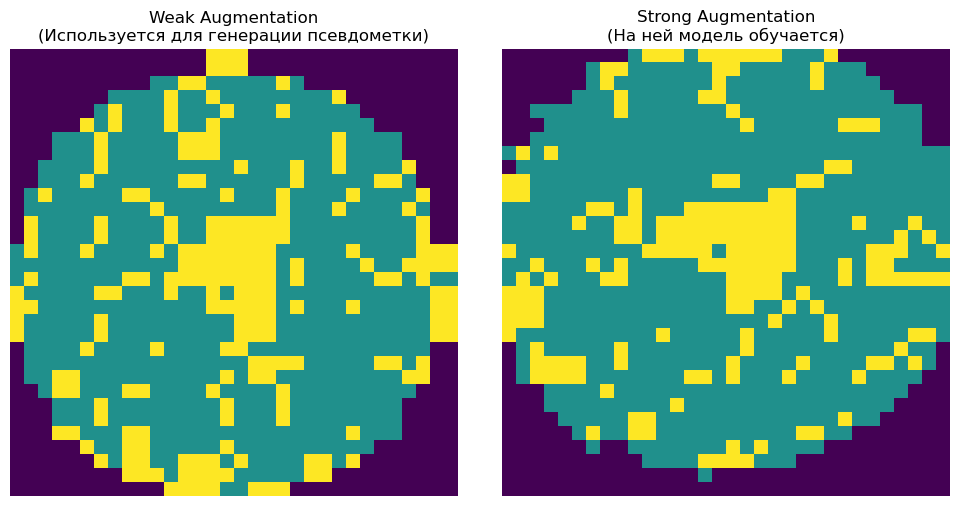

Формат тензоров в SSL батче: torch.Size([64, 1, 32, 32])


In [22]:
# Извлекаем один батч из неразмеченных данных
images_weak, images_strong = next(iter(train_unlabeled_loader))

# Берём самую первую пластину из батча
# Убираем канал для отображения в matplotlib: (1, 32, 32) -> (32, 32)
img_w = images_weak[0].squeeze().numpy()
img_s = images_strong[0].squeeze().numpy()

# Рисуем сравнение
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Слабая аугментация (обычно просто поворот или флип)
axes[0].imshow(img_w, cmap='viridis')
axes[0].set_title("Weak Augmentation\n(Используется для генерации псевдометки)")
axes[0].axis('off')

# Сильная аугментация (с выбиванием пикселей CoarseDropout и искажениями)
axes[1].imshow(img_s, cmap='viridis')
axes[1].set_title("Strong Augmentation\n(На ней модель обучается)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Формат тензоров в SSL батче: {images_weak.shape}") # Должно быть (64, 1, 32, 32)

In [25]:
import torch
import torch.nn.functional as F

class WaferSSLLoss(torch.nn.Module):
    def __init__(self, strategy='fixmatch', threshold=0.95, lambda_u=1.0,
                 num_classes=8, momentum=0.999, min_threshold=0.3,
                 dynamic_threshold=True, mt_temperature=1.0):
        """
        FixMatch loss with ClimEx-style momentum-updated per-class dynamic thresholds.
        """
        super().__init__()
        self.strategy = strategy
        self.strategy_override = None 
        self.threshold = threshold          # base/global threshold
        self.lambda_u = lambda_u
        self.num_classes = num_classes
        self.momentum = momentum
        self.min_threshold = min_threshold  # floor so a class threshold never collapses to 0 early on
        self.dynamic_threshold = dynamic_threshold
        self.mt_temperature = mt_temperature
        self.ce_loss = torch.nn.CrossEntropyLoss()

        # running per-class average confidence, EMA-updated each batch
        self.register_buffer('class_conf_ema', torch.zeros(num_classes))
        # tracks whether a class has been seen yet, to avoid biasing the EMA with the zero-init
        self.register_buffer('class_seen', torch.zeros(num_classes, dtype=torch.bool))

    def _update_class_thresholds(self, max_probs, pseudo_labels):
        # Update EMA confidence per class using this batch's pseudo-labels
        for c in range(self.num_classes):
            class_mask = (pseudo_labels == c)
            if class_mask.sum() > 0:
                batch_mean_conf = max_probs[class_mask].mean()
                if self.class_seen[c]:
                    self.class_conf_ema[c] = (
                        self.momentum * self.class_conf_ema[c]
                        + (1 - self.momentum) * batch_mean_conf
                    )
                else:
                    self.class_conf_ema[c] = batch_mean_conf
                    self.class_seen[c] = True

        # Normalize relative to the most-confident class, scale by base threshold
        if self.class_seen.any():
            max_conf = self.class_conf_ema[self.class_seen].max()
            class_thresholds = self.threshold * (self.class_conf_ema / max_conf.clamp(min=1e-8))
            class_thresholds = class_thresholds.clamp(min=self.min_threshold, max=self.threshold)
        else:
            # nothing seen yet -> fall back to global threshold for all classes
            class_thresholds = torch.full((self.num_classes,), self.threshold,
                                           device=self.class_conf_ema.device)
        return class_thresholds

    def forward(self, model, x_labeled, y_labeled, x_unlabeled_weak=None, x_unlabeled_strong=None,
                teacher_model=None):   # <-- новый параметр, по умолчанию None
        active_strategy = self.strategy_override or self.strategy

        logits_labeled = model(x_labeled)
        loss_labeled = self.ce_loss(logits_labeled, y_labeled)

        if active_strategy == 'supervised_only' or x_unlabeled_weak is None:
            return loss_labeled, loss_labeled, torch.tensor(0.0, device=loss_labeled.device), torch.tensor(0.0)

        loss_unlabeled = torch.tensor(0.0, device=x_labeled.device)
        mask_ratio = torch.tensor(0.0)

        if active_strategy == 'fixmatch':
            with torch.no_grad():
                pseudo_label_source = teacher_model if teacher_model is not None else model
                logits_weak = pseudo_label_source(x_unlabeled_weak)
                pseudo_labels_probs = F.softmax(logits_weak, dim=-1)
                max_probs, pseudo_labels = torch.max(pseudo_labels_probs, dim=-1)

                if self.dynamic_threshold:
                    class_thresholds = self._update_class_thresholds(max_probs, pseudo_labels)
                    sample_thresholds = class_thresholds[pseudo_labels]
                    mask = max_probs.ge(sample_thresholds).float()
                else:
                    # Ванильный FixMatch: один глобальный порог для всех классов
                    mask = max_probs.ge(self.threshold).float()

                mask_ratio = mask.mean()

            logits_strong = model(x_unlabeled_strong)   # студент всегда учится сам, независимо от teacher
            raw_loss_unlabeled = F.cross_entropy(logits_strong, pseudo_labels, reduction='none')
            loss_unlabeled = (raw_loss_unlabeled * mask).mean()
            
        elif active_strategy == 'mean_teacher':
            with torch.no_grad():
                # Teacher и student видят ОДИНАКОВЫЙ вход (weak aug)
                # Шум между ними создаётся только разницей в весах (EMA vs текущие)
                logits_teacher = teacher_model(x_unlabeled_weak) if teacher_model is not None else model(x_unlabeled_weak)
                probs_teacher = F.softmax(logits_teacher / self.mt_temperature, dim=-1).detach()

            # Student тоже на weak aug (не на strong, как в FixMatch)
            logits_student = model(x_unlabeled_weak)
            probs_student = F.softmax(logits_student / self.mt_temperature, dim=-1)

            # Consistency loss: MSE между softmax-выходами
            loss_unlabeled = F.mse_loss(probs_student, probs_teacher)

            # mask_ratio = 1.0 -- нет порога, все примеры участвуют
            mask_ratio = torch.tensor(1.0)


        total_loss = loss_labeled + self.lambda_u * loss_unlabeled
        return total_loss, loss_labeled, loss_unlabeled, mask_ratio

In [11]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model(model, dataloader, device):
    """
    Проверяет модель на тестовой/валидационной выборке.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            
            outputs = model(images)
            preds = torch.argmax(outputs, dim=-1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # Считаем метрики
    acc = accuracy_score(all_labels, all_preds)
    # macro f1 учитывает дисбаланс классов
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) 
    
    return acc, f1

In [12]:
class ModelEMA:
    """
    Хранит EMA-копию весов модели. Не обучается напрямую — 
    обновляется вручную после каждого optimizer.step().
    """
    def __init__(self, model, decay=0.999):
        self.ema_model = copy.deepcopy(model)
        self.ema_model.eval()
        for p in self.ema_model.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        ema_params = dict(self.ema_model.named_parameters())
        for name, param in model.named_parameters():
            ema_params[name].mul_(self.decay).add_(param.detach(), alpha=1 - self.decay)
        # буферы (например, если позже добавите BatchNorm) копируем напрямую
        ema_buffers = dict(self.ema_model.named_buffers())
        for name, buf in model.named_buffers():
            ema_buffers[name].copy_(buf)

In [13]:
num_epochs = 30

def train_pipeline(model, labeled_loader, unlabeled_loader, val_loader,
                    criterion, epochs, lr, device, warmup_epochs=3,
                    use_ema_teacher=False, ema_decay=0.999,
                    grad_clip_norm=None, verbose=True):

    # history теперь локальный, а не глобальный -- иначе повторные вызовы
    # train_pipeline (например, в цикле подбора warmup_epochs) будут перезаписывать
    # или путать результаты друг друга
    history = {'val_acc': [], 'val_f1': [], 'total_loss': []}

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    lr_warmup_epochs = 2
    warmup_scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.05, end_factor=1.0, total_iters=lr_warmup_epochs)
    cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs - lr_warmup_epochs)
    scheduler = optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[lr_warmup_epochs])

    ema = ModelEMA(model, decay=ema_decay) if use_ema_teacher else None

    base_lambda_u = criterion.lambda_u
    if verbose:
        print(f"Старт обучения в режиме: {criterion.strategy.upper()} | EMA teacher: {use_ema_teacher}")

    for epoch in range(epochs):
        model.train()
        if epoch < warmup_epochs:
            criterion.strategy_override = 'supervised_only'
        else:
            criterion.strategy_override = None
            ramp_epoch = epoch - warmup_epochs
            criterion.lambda_u = min(1.0, (ramp_epoch + 1) / 3) * base_lambda_u

        unlabeled_iter = iter(unlabeled_loader)
        running_total_loss = running_l_loss = running_u_loss = running_mask = 0.0

        pbar = tqdm(labeled_loader, desc=f"Epoch {epoch+1}/{epochs}", disable=not verbose)
        for x_labeled, y_labeled in pbar:
            x_labeled, y_labeled = x_labeled.to(device), y_labeled.to(device)
            try:
                x_unlabeled_weak, x_unlabeled_strong = next(unlabeled_iter)
            except StopIteration:
                unlabeled_iter = iter(unlabeled_loader)
                x_unlabeled_weak, x_unlabeled_strong = next(unlabeled_iter)
            x_unlabeled_weak, x_unlabeled_strong = x_unlabeled_weak.to(device), x_unlabeled_strong.to(device)

            total_loss, loss_l, loss_u, mask_ratio = criterion(
                model, x_labeled, y_labeled, x_unlabeled_weak, x_unlabeled_strong,
                teacher_model=(ema.ema_model if ema is not None else None)
            )

            optimizer.zero_grad()
            total_loss.backward()
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
            optimizer.step()

            if ema is not None:
                ema.update(model)

            running_total_loss += total_loss.item()
            running_l_loss += loss_l.item()
            running_u_loss += loss_u.item() if isinstance(loss_u, torch.Tensor) else loss_u
            running_mask += mask_ratio.item() if isinstance(mask_ratio, torch.Tensor) else mask_ratio
            pbar.set_postfix({'Loss': f"{total_loss.item():.4f}", 'Mask': f"{running_mask/len(labeled_loader):.2f}"})

        scheduler.step()

        # Валидация -- один-единственный раз за эпоху, на eval_model (teacher, если он есть)
        # test_loader здесь НЕ используется вообще -- он трогается только один раз,
        # после того как best_warmup выбран по val
        eval_model = ema.ema_model if ema is not None else model
        val_acc, val_f1 = evaluate_model(eval_model, val_loader, device)

        if verbose:
            print(f"--- Эпоха {epoch+1} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f} ---")

        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['total_loss'].append(running_total_loss)

    final_model = ema.ema_model if ema is not None else model
    return model, final_model, history

In [14]:
# 1. Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Используем устройство: {device}")

# 2. Подбор warmup_epochs на валидации
warmup_candidates = [0, 2, 3, 5, 7]
results = {}
histories = {}   # сохраним историю каждого прогона -- пригодится для графиков в дипломе

for wu in warmup_candidates:
    print(f"\n=== Тестируем warmup_epochs={wu} ===")

    vit_model_trial = create_vit_tiny_model(num_classes=8, img_size=32, in_chans=1).to(device)
    criterion_trial = WaferSSLLoss(
        strategy='fixmatch', threshold=0.85, lambda_u=1.0, num_classes=8
    ).to(device)

    _, teacher_model_trial, history_trial = train_pipeline(
        model=vit_model_trial,
        labeled_loader=train_labeled_loader,
        unlabeled_loader=train_unlabeled_loader,
        val_loader=val_loader,
        criterion=criterion_trial,
        epochs=num_epochs,
        lr=5e-4,
        device=device,
        warmup_epochs=wu,
        use_ema_teacher=True,
        ema_decay=0.99,
        grad_clip_norm=1.0,
        verbose=False
    )

    # среднее по последним 3 эпохам -- устойчивее к шуму, чем одна последняя точка
    best_val_f1 = np.mean(history_trial['val_f1'][-3:])
    results[wu] = best_val_f1
    histories[wu] = history_trial
    print(f"warmup_epochs={wu} -> Val Macro F1 (среднее по последним 3 эпохам): {best_val_f1:.4f}")

best_warmup = max(results, key=results.get)
print(f"\n=== Лучший warmup_epochs: {best_warmup} (Val F1={results[best_warmup]:.4f}) ===")
print(f"Все результаты: {results}")

Используем устройство: mps

=== Тестируем warmup_epochs=0 ===
warmup_epochs=0 -> Val Macro F1 (среднее по последним 3 эпохам): 0.6038

=== Тестируем warmup_epochs=2 ===
warmup_epochs=2 -> Val Macro F1 (среднее по последним 3 эпохам): 0.6102

=== Тестируем warmup_epochs=3 ===
warmup_epochs=3 -> Val Macro F1 (среднее по последним 3 эпохам): 0.5904

=== Тестируем warmup_epochs=5 ===
warmup_epochs=5 -> Val Macro F1 (среднее по последним 3 эпохам): 0.5799

=== Тестируем warmup_epochs=7 ===
warmup_epochs=7 -> Val Macro F1 (среднее по последним 3 эпохам): 0.5873

=== Лучший warmup_epochs: 2 (Val F1=0.6102) ===
Все результаты: {0: 0.6037902291185322, 2: 0.6101849219819901, 3: 0.5904340394262931, 5: 0.5798724737416355, 7: 0.5873358848260378}


In [15]:
# 3. Финальное обучение с лучшим warmup_epochs -- тест трогаем только здесь, один раз
vit_model = create_vit_tiny_model(num_classes=8, img_size=32, in_chans=1).to(device)

ssl_criterion_weighted = WaferSSLLoss(
    strategy='fixmatch',
    threshold=0.85,
    lambda_u=1.0,
    num_classes=8
).to(device)

student_final, teacher_final, history_final = train_pipeline(
    model=vit_model,
    labeled_loader=train_labeled_loader,
    unlabeled_loader=train_unlabeled_loader,
    val_loader=val_loader,
    criterion=ssl_criterion_weighted,
    epochs=num_epochs,
    lr=5e-4,
    device=device,
    warmup_epochs=best_warmup,
    use_ema_teacher=True,
    ema_decay=0.99,
    grad_clip_norm=1.0,
    verbose=True
)

test_acc, test_f1 = evaluate_model(teacher_final, test_loader, device)
print(f"\n=== ИТОГ на test (warmup_epochs={best_warmup}) ===")
print(f"Test Acc: {test_acc*100:.2f}% | Test Macro F1: {test_f1:.4f}")

trained_vit_weighted = teacher_final   # чтобы не сломать остальной код ноутбука, который ссылается на это имя

Старт обучения в режиме: FIXMATCH | EMA teacher: True



--- Эпоха 1 | Val Acc: 41.45% | Val F1: 0.1125 ---



--- Эпоха 2 | Val Acc: 37.10% | Val F1: 0.1650 ---



--- Эпоха 3 | Val Acc: 60.87% | Val F1: 0.2606 ---



--- Эпоха 4 | Val Acc: 56.52% | Val F1: 0.2539 ---


...


--- Эпоха 26 | Val Acc: 80.87% | Val F1: 0.5973 ---



--- Эпоха 27 | Val Acc: 80.87% | Val F1: 0.5975 ---



--- Эпоха 28 | Val Acc: 81.16% | Val F1: 0.6117 ---



--- Эпоха 29 | Val Acc: 80.87% | Val F1: 0.6076 ---



--- Эпоха 30 | Val Acc: 80.87% | Val F1: 0.6076 ---

=== ИТОГ на test (warmup_epochs=2) ===
Test Acc: 79.70% | Test Macro F1: 0.5723


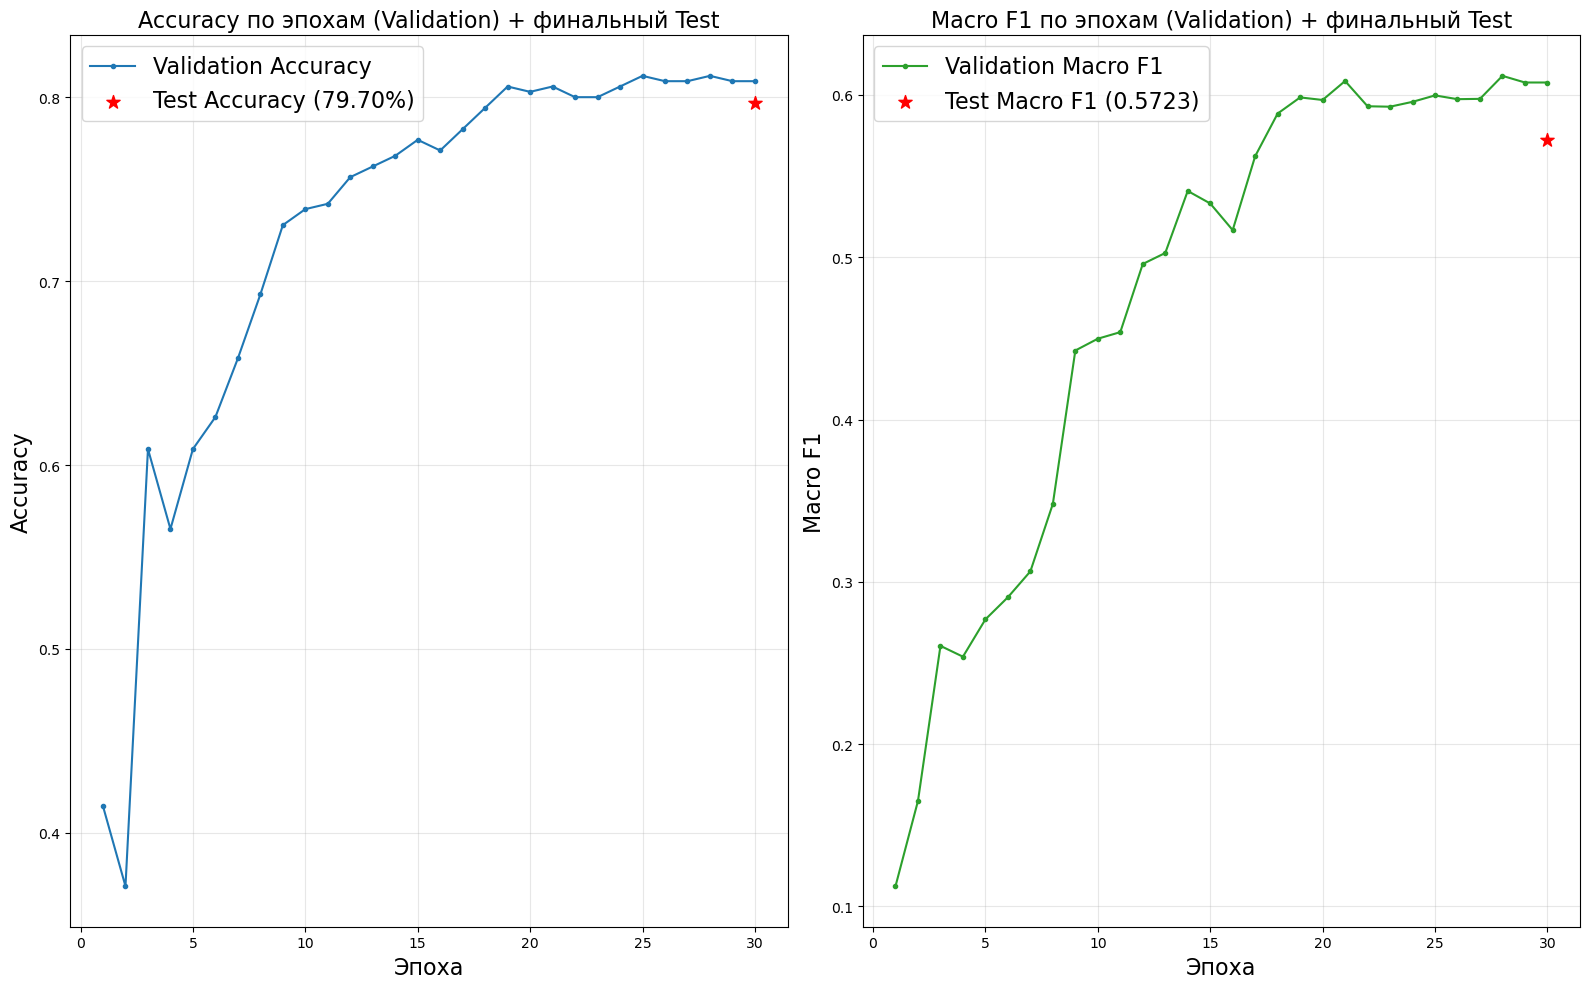

In [21]:
epochs_range = range(1, len(history_final['val_acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Accuracy
axes[0].plot(epochs_range, history_final['val_acc'], marker='o', markersize=3, label='Validation Accuracy', color='tab:blue')
axes[0].scatter([len(epochs_range)], [test_acc], color='red', s=100, zorder=5, marker='*', label=f'Test Accuracy ({test_acc*100:.2f}%)')
axes[0].set_xlabel('Эпоха', fontsize=16)
axes[0].set_ylabel('Accuracy', fontsize=16)
axes[0].set_title('Accuracy по эпохам (Validation) + финальный Test', fontsize=16)
axes[0].legend(fontsize=16)
axes[0].grid(alpha=0.3)

# F1
axes[1].plot(epochs_range, history_final['val_f1'], marker='o', markersize=3, label='Validation Macro F1', color='tab:green')
axes[1].scatter([len(epochs_range)], [test_f1], color='red', s=100, zorder=5, marker='*', label=f'Test Macro F1 ({test_f1:.4f})')
axes[1].set_xlabel('Эпоха', fontsize=16)
axes[1].set_ylabel('Macro F1', fontsize=16)
axes[1].set_title('Macro F1 по эпохам (Validation) + финальный Test', fontsize=16)
axes[1].legend(fontsize=16)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
configs = [
    {
        'name': 'Vanilla FixMatch',
        'dynamic_threshold': False,
        'warmup_epochs': 0,
        'use_ema_teacher': False,
        'strategy': 'fixmatch',
        'color': 'tab:gray'
    },
    {
        'name': 'FixMatch + Warmup + Dynamic Threshold',
        'dynamic_threshold': True,
        'warmup_epochs': best_warmup,
        'use_ema_teacher': False,
        'strategy': 'fixmatch',
        'color': 'tab:orange'
    },
    {
        'name': 'Mean Teacher (чистый)',
        'dynamic_threshold': False,   # не используется в mean_teacher, но нужен для инициализации
        'warmup_epochs': best_warmup,
        'use_ema_teacher': True,      # EMA teacher обязателен
        'strategy': 'mean_teacher',
        'color': 'tab:green'
    },
    {
        'name': 'FixMatch + Warmup + Dynamic Threshold + EMA Teacher',
        'dynamic_threshold': True,
        'warmup_epochs': best_warmup,
        'use_ema_teacher': True,
        'strategy': 'fixmatch',
        'color': 'tab:blue'
    },
]

results_summary = {}   # name -> {'history':..., 'test_acc':..., 'test_f1':...}

for cfg in configs:
    print(f"\n{'='*60}\nЗапуск: {cfg['name']}\n{'='*60}")

    model_run = create_vit_tiny_model(num_classes=8, img_size=32, in_chans=1).to(device)
    criterion_run = WaferSSLLoss(
        strategy=cfg['strategy'],          # <-- было захардкожено 'fixmatch'
        threshold=0.85,
        lambda_u=1.0,
        num_classes=8,
        dynamic_threshold=cfg['dynamic_threshold']
    ).to(device)

    _, final_model_run, history_run = train_pipeline(
        model=model_run,
        labeled_loader=train_labeled_loader,
        unlabeled_loader=train_unlabeled_loader,
        val_loader=val_loader,
        criterion=criterion_run,
        epochs=num_epochs,
        lr=5e-4,
        device=device,
        warmup_epochs=cfg['warmup_epochs'],
        use_ema_teacher=cfg['use_ema_teacher'],
        ema_decay=0.99,
        grad_clip_norm=1.0,
        verbose=False
    )

    test_acc_run, test_f1_run = evaluate_model(final_model_run, test_loader, device)
    print(f"{cfg['name']} -> Test Acc: {test_acc_run*100:.2f}% | Test F1: {test_f1_run:.4f}")

    results_summary[cfg['name']] = {
        'history': history_run,
        'test_acc': test_acc_run,
        'test_f1': test_f1_run,
        'color': cfg['color']
    }


Запуск: Vanilla FixMatch
Vanilla FixMatch -> Test Acc: 80.02% | Test F1: 0.6684

Запуск: FixMatch + Warmup + Dynamic Threshold
FixMatch + Warmup + Dynamic Threshold -> Test Acc: 78.84% | Test F1: 0.5586

Запуск: Mean Teacher (чистый)
Mean Teacher (чистый) -> Test Acc: 80.56% | Test F1: 0.6542

Запуск: FixMatch + Warmup + Dynamic Threshold + EMA Teacher
FixMatch + Warmup + Dynamic Threshold + EMA Teacher -> Test Acc: 79.74% | Test F1: 0.5675


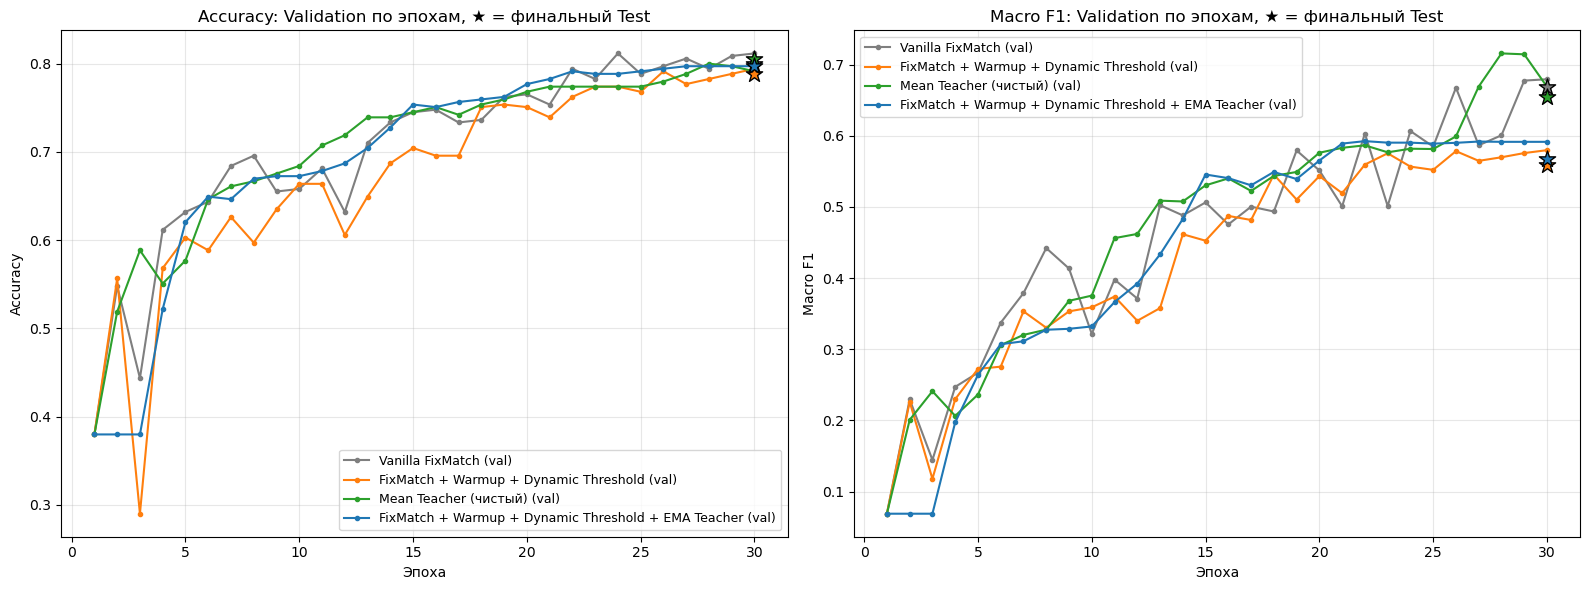


--- Итоговая сводка ---
Vanilla FixMatch                                        | Test Acc: 80.02% | Test F1: 0.6684
FixMatch + Warmup + Dynamic Threshold                   | Test Acc: 78.84% | Test F1: 0.5586
Mean Teacher (чистый)                                   | Test Acc: 80.56% | Test F1: 0.6542
FixMatch + Warmup + Dynamic Threshold + EMA Teacher     | Test Acc: 79.74% | Test F1: 0.5675


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results_summary.items():
    epochs_range = range(1, len(res['history']['val_acc']) + 1)
    color = res['color']

    # Accuracy
    axes[0].plot(epochs_range, res['history']['val_acc'], marker='o', markersize=3,
                 label=f"{name} (val)", color=color)
    axes[0].scatter([len(epochs_range)], [res['test_acc']], color=color, s=150,
                     marker='*', zorder=5, edgecolors='black')

    # F1
    axes[1].plot(epochs_range, res['history']['val_f1'], marker='o', markersize=3,
                 label=f"{name} (val)", color=color)
    axes[1].scatter([len(epochs_range)], [res['test_f1']], color=color, s=150,
                     marker='*', zorder=5, edgecolors='black')

axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy: Validation по эпохам, ★ = финальный Test')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Macro F1: Validation по эпохам, ★ = финальный Test')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Сводная таблица
print("\n--- Итоговая сводка ---")
for name, res in results_summary.items():
    print(f"{name:55s} | Test Acc: {res['test_acc']*100:5.2f}% | Test F1: {res['test_f1']:.4f}")